# 02_clean_occurrences.ipynb

GBIF Darwin Core Archive cleaning workflow for ecological connectivity analysis.

This notebook:
- extracts DwC-A archives
- loads occurrence tables
- validates coordinates
- removes problematic records
- converts to GeoDataFrame
- exports GIS-ready layers for QGIS
- stores outputs in the project architecture


## Imports

In [4]:
import zipfile
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np

from shapely.geometry import Point

import matplotlib.pyplot as plt


In [5]:
import folium
from folium.plugins import MarkerCluster
from IPython.display import display

## Project Paths

In [6]:
PROJECT_ROOT = Path.cwd().parent

RAW_GBIF = PROJECT_ROOT / 'data' / 'raw' / 'gbif'
INTERIM_GBIF = PROJECT_ROOT / 'data' / 'interim' / 'gbif'
PROCESSED_SPECIES = PROJECT_ROOT / 'data' / 'processed' / 'species'

INTERIM_GBIF.mkdir(parents=True, exist_ok=True)
PROCESSED_SPECIES.mkdir(parents=True, exist_ok=True)


In [7]:
# Change species here
SPECIES = 'Narcissus_cavanillesii'

ZIP_PATH = RAW_GBIF / f'{SPECIES}.zip'

EXTRACT_DIR = INTERIM_GBIF / SPECIES
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print(ZIP_PATH)
print(EXTRACT_DIR)


/home/linda/Documents/myData/data-management/data/raw/gbif/Narcissus_cavanillesii.zip
/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii


In [8]:
QA_DIR = PROJECT_ROOT / 'data' / 'qa' / SPECIES
QA_DIR.mkdir(parents=True, exist_ok=True)

removed_csv_path = QA_DIR / f'{SPECIES}_removed_records.csv'
review_geojson_path = QA_DIR / f'{SPECIES}_review_points.geojson'

## Extract Darwin Core Archive

In [9]:
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print('Archive extracted successfully.')


Archive extracted successfully.


## Inspect Extracted Files

In [10]:
list(EXTRACT_DIR.glob('*'))


[PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/rights.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/meta.xml'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/multimedia.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/verbatim.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/citations.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/occurrence.txt'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/metadata.xml'),
 PosixPath('/home/linda/Documents/myData/data-management/data/interim/gbif/Narcissus_cavanillesii/dataset')]

## Load Occurrence Table

In [11]:
occurrence_file = EXTRACT_DIR / 'occurrence.txt'

df = pd.read_csv(
    occurrence_file,
    sep='\t',
    low_memory=False
)

print(df.shape)
df.head()


(5, 230)


,gbifID,accessRights,bibliographicCitation,language,license,modified,publisher,references,rightsHolder,type,...,publishedByGbifRegion,level0Gid,level0Name,level1Gid,level1Name,level2Gid,level2Name,level3Gid,level3Name,iucnRedListCategory
0,4887207678,NaN,NaN,NaN,CC_BY_NC_4_0,2024-01-31T12:05:00Z,NaN,NaN,Stichting Observation International,NaN,...,EUROPE,PRT,Portugal,PRT.14_1,Portalegre,PRT.14.7_1,Elvas,PRT.14.7.1_1,"Ajuda, Salvador E Santo Ildefons",LC
1,3961085365,NaN,NaN,NaN,CC_BY_NC_4_0,2026-03-20T16:37:50Z,NaN,https://www.inaturalist.org/observations/14057...,Rafael António,NaN,...,NORTH_AMERICA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LC
2,3759098886,NaN,NaN,NaN,CC_BY_NC_4_0,2026-03-20T16:37:08Z,NaN,https://www.inaturalist.org/observations/10836...,davidphillips1968,NaN,...,NORTH_AMERICA,ESP,Spain,ESP.11_1,Extremadura,ESP.11.1_1,Badajoz,ESP.11.1.5_1,n.a. (43),LC
3,1075236115,NaN,NaN,pt,CC_BY_NC_4_0,2016-02-15T00:00:00Z,NaN,NaN,NaN,NaN,...,EUROPE,PRT,Portugal,PRT.14_1,Portalegre,PRT.14.7_1,Elvas,PRT.14.7.1_1,"Ajuda, Salvador E Santo Ildefons",LC
4,1075133338,NaN,NaN,pt,CC_BY_NC_4_0,2016-02-15T00:00:00Z,NaN,NaN,NaN,NaN,...,EUROPE,PRT,Portugal,PRT.14_1,Portalegre,PRT.14.7_1,Elvas,PRT.14.7.1_1,"Ajuda, Salvador E Santo Ildefons",LC


## Keep Essential Columns

In [12]:
keep_cols = [
    'gbifID',
    'species',
    'decimalLatitude',
    'decimalLongitude',
    'countryCode',
    'eventDate',
    'basisOfRecord',
    'coordinateUncertaintyInMeters',
    'year',
    'month',
    'day'
]

df = df[keep_cols].copy()

print(df.shape)


(5, 11)


## Remove Missing Coordinates

In [13]:
df = df.dropna(
    subset=['decimalLatitude', 'decimalLongitude']
)

print(df.shape)


(5, 11)


## Convert Coordinates to Numeric

In [14]:
df['decimalLatitude'] = pd.to_numeric(
    df['decimalLatitude'],
    errors='coerce'
)

df['decimalLongitude'] = pd.to_numeric(
    df['decimalLongitude'],
    errors='coerce'
)

df = df.dropna(
    subset=['decimalLatitude', 'decimalLongitude']
)

print(df.shape)


(5, 11)


## Remove Invalid Coordinates

In [15]:
df = df[
    (df['decimalLatitude'] >= -90) &
    (df['decimalLatitude'] <= 90) &
    (df['decimalLongitude'] >= -180) &
    (df['decimalLongitude'] <= 180)
]

print(df.shape)


(5, 11)


## Remove Zero Coordinates

In [16]:
df = df[
    ~(
        (df['decimalLatitude'] == 0) &
        (df['decimalLongitude'] == 0)
    )
]

print(df.shape)


(5, 11)


## Remove Duplicate Occurrences

In [17]:
df = df.drop_duplicates(
    subset=[
        'species',
        'decimalLatitude',
        'decimalLongitude'
    ]
)

print(df.shape)


(4, 11)


## Filter Coordinate Uncertainty

In [18]:
df['coordinateUncertaintyInMeters'] = pd.to_numeric(
    df['coordinateUncertaintyInMeters'],
    errors='coerce'
)

MAX_UNCERTAINTY = 5000

df = df[
    (
        df['coordinateUncertaintyInMeters'].isna()
    ) |
    (
        df['coordinateUncertaintyInMeters'] <= MAX_UNCERTAINTY
    )
]

print(df.shape)


(2, 11)


## Convert to GeoDataFrame

In [19]:
geometry = [
    Point(xy)
    for xy in zip(
        df['decimalLongitude'],
        df['decimalLatitude']
    )
]

gdf = gpd.GeoDataFrame(
    df,
    geometry=geometry,
    crs='EPSG:4326'
)

print(gdf.shape)
gdf.head()


(2, 12)


,gbifID,species,decimalLatitude,decimalLongitude,countryCode,eventDate,basisOfRecord,coordinateUncertaintyInMeters,year,month,day,geometry
0,4887207678,Narcissus cavanillesii,38.77758,-7.170905,PT,2020-09-27,HUMAN_OBSERVATION,NaN,2020,9,27,POINT (-7.1709 38.77758)
3,1075236115,Narcissus cavanillesii,38.79013,-7.215310,PT,2014-10-12,HUMAN_OBSERVATION,NaN,2014,10,12,POINT (-7.21531 38.79013)


## Reproject to EPSG:3035

In [20]:
gdf_3035 = gdf.to_crs('EPSG:3035')

print(gdf_3035.crs)


EPSG:3035


## Quick Spatial Plot

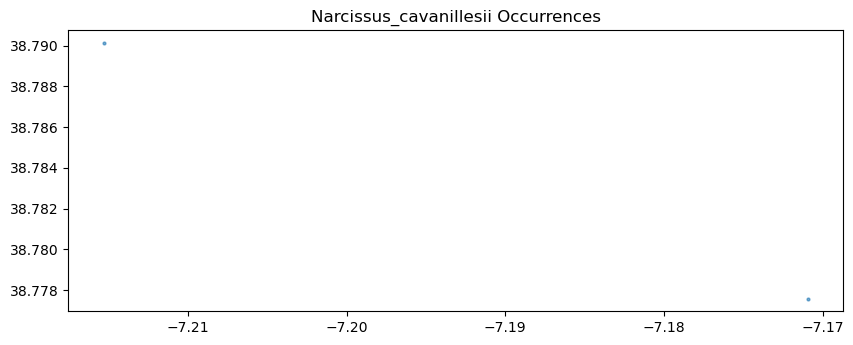

In [21]:
fig, ax = plt.subplots(figsize=(10, 10))

gdf.plot(
    ax=ax,
    markersize=4,
    alpha=0.6
)

ax.set_title(f'{SPECIES} Occurrences')

plt.show()


## Output Paths

In [22]:
SPECIES_DIR = PROCESSED_SPECIES / SPECIES
SPECIES_DIR.mkdir(parents=True, exist_ok=True)

gpkg_path = SPECIES_DIR / f'{SPECIES}.gpkg'
geojson_path = SPECIES_DIR / f'{SPECIES}.geojson'
parquet_path = SPECIES_DIR / f'{SPECIES}.parquet'
csv_path = SPECIES_DIR / f'{SPECIES}.csv'

print(SPECIES_DIR)


/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii


## Export GeoPackage

In [23]:
gdf_3035.to_file(
    gpkg_path,
    driver='GPKG'
)

print(gpkg_path)


/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.gpkg


## Export GeoJSON

In [24]:
gdf.to_file(
    geojson_path,
    driver='GeoJSON'
)

print(geojson_path)


/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.geojson


## Export GeoParquet

In [25]:
gdf.to_parquet(parquet_path)

print(parquet_path)


/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.parquet


## Export CSV

In [26]:
gdf.drop(columns='geometry').to_csv(
    csv_path,
    index=False
)

print(csv_path)


/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.csv


## QA Summary

In [27]:
print('FINAL SUMMARY')
print('-' * 40)

print(f'Species: {SPECIES}')
print(f'Records: {len(gdf)}')
print(f'CRS: {gdf.crs}')

print('\nOutputs:')
print(gpkg_path)
print(geojson_path)
print(parquet_path)
print(csv_path)


FINAL SUMMARY
----------------------------------------
Species: Narcissus_cavanillesii
Records: 2
CRS: EPSG:4326

Outputs:
/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.gpkg
/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.geojson
/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.parquet
/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii.csv


## Interactive OpenStreetMap QA (manual validation)

In [28]:
review_gdf = gdf.copy()

center_lat = review_gdf['decimalLatitude'].mean()
center_lon = review_gdf['decimalLongitude'].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

cluster = MarkerCluster().add_to(m)

for _, row in review_gdf.iterrows():

    popup = f"""
    <b>GBIF ID:</b> {row['gbifID']}<br>
    <b>Species:</b> {row['species']}<br>
    <b>Country:</b> {row['countryCode']}<br>
    <b>Date:</b> {row['eventDate']}<br>
    <b>Uncertainty:</b> {row['coordinateUncertaintyInMeters']}
    """

    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=4,
        color='red',
        fill=True,
        fill_opacity=0.6,
        popup=folium.Popup(popup, max_width=300)
    ).add_to(cluster)

display(m)

## Manual removal (cherry-pick bad records)

In [29]:
# Paste GBIF IDs you want to remove after inspecting the map
REMOVE_GBIF_IDS = [
    #5024499210,
   #3329219793,
]

REMOVE_GBIF_IDS = [str(x) for x in REMOVE_GBIF_IDS]

print("Before removal:", len(gdf))

Before removal: 2


In [30]:
removed_records = gdf[
    gdf['gbifID'].astype(str).isin(REMOVE_GBIF_IDS)
].copy()

print("Removed records:", len(removed_records))

if len(removed_records) > 0:
    removed_records.drop(columns='geometry').to_csv(
        removed_csv_path,
        index=False
    )
    print("Saved removed log:", removed_csv_path)

Removed records: 0


In [31]:
gdf = gdf[
    ~gdf['gbifID'].astype(str).isin(REMOVE_GBIF_IDS)
].copy()

print("Remaining records:", len(gdf))

Remaining records: 2


In [32]:
clean_center_lat = gdf['decimalLatitude'].mean()
clean_center_lon = gdf['decimalLongitude'].mean()

clean_map = folium.Map(
    location=[clean_center_lat, clean_center_lon],
    zoom_start=5,
    tiles='OpenStreetMap'
)

for _, row in gdf.iterrows():

    popup = f"""
    <b>GBIF ID:</b> {row['gbifID']}<br>
    <b>Species:</b> {row['species']}<br>
    <b>Country:</b> {row['countryCode']}
    """

    folium.CircleMarker(
        location=[row['decimalLatitude'], row['decimalLongitude']],
        radius=4,
        color='green',
        fill=True,
        fill_opacity=0.6,
        popup=popup
    ).add_to(clean_map)

display(clean_map)

In [33]:
clean_map.save(
    SPECIES_DIR / f'{SPECIES}_clean_map.html'
)

In [34]:
review_gdf.to_file(
    review_geojson_path,
    driver='GeoJSON'
)

print(review_geojson_path)

/home/linda/Documents/myData/data-management/data/qa/Narcissus_cavanillesii/Narcissus_cavanillesii_review_points.geojson


In [35]:
review_geojson_path

PosixPath('/home/linda/Documents/myData/data-management/data/qa/Narcissus_cavanillesii/Narcissus_cavanillesii_review_points.geojson')

In [36]:
# Update path 

import geopandas as gpd

path = "/home/linda/Documents/myData/data-management/data/qa/Narcissus_cavanillesii/Narcissus_cavanillesii_review_points.geojson"

gdf = gpd.read_file(path, engine="fiona")

gdf.head()

,gbifID,species,decimalLatitude,decimalLongitude,countryCode,eventDate,basisOfRecord,coordinateUncertaintyInMeters,year,month,day,geometry
0,4887207678,Narcissus cavanillesii,38.77758,-7.170905,PT,2020-09-27,HUMAN_OBSERVATION,None,2020,9,27,POINT (-7.1709 38.77758)
1,1075236115,Narcissus cavanillesii,38.79013,-7.215310,PT,2014-10-12,HUMAN_OBSERVATION,None,2014,10,12,POINT (-7.21531 38.79013)


In [37]:
gdf["coordinateUncertaintyInMeters"].describe()

count       0
unique      0
top       NaN
freq      NaN
Name: coordinateUncertaintyInMeters, dtype: object

In [38]:
gdf["coordinateUncertaintyInMeters"] = gdf["coordinateUncertaintyInMeters"].astype(float)

In [39]:
gdf_clean = gdf[gdf["coordinateUncertaintyInMeters"] <= 30].copy()

In [40]:
gdf_clean = gdf_clean.dropna(subset=["coordinateUncertaintyInMeters"])

In [41]:
print(len(gdf), "original records")
print(len(gdf_clean), "after cleaning")

2 original records
0 after cleaning


In [42]:
# Update path & layer name here

gpkg_path = "/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii_clean.gpkg"

gdf_clean.to_file(
    gpkg_path,
    layer="spp_clean",
    driver="GPKG"
)

print(gpkg_path)

/home/linda/Documents/myData/data-management/data/processed/species/Narcissus_cavanillesii/Narcissus_cavanillesii_clean.gpkg
